In [117]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings as w
w.filterwarnings('ignore')

In [ ]:
# importing and exploring data

In [3]:
df=pd.read_csv("healthcare_dataset.csv")
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


In [4]:
df.columns

Index(['Name', 'Age', 'Gender', 'Blood Type', 'Medical Condition',
       'Date of Admission', 'Doctor', 'Hospital', 'Insurance Provider',
       'Billing Amount', 'Room Number', 'Admission Type', 'Discharge Date',
       'Medication', 'Test Results'],
      dtype='object')

In [5]:
df.tail()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
55495,eLIZABeTH jaCkSOn,42,Female,O+,Asthma,2020-08-16,Joshua Jarvis,Jones-Thompson,Blue Cross,2650.714952,417,Elective,2020-09-15,Penicillin,Abnormal
55496,KYle pEREz,61,Female,AB-,Obesity,2020-01-23,Taylor Sullivan,Tucker-Moyer,Cigna,31457.797307,316,Elective,2020-02-01,Aspirin,Normal
55497,HEATher WaNG,38,Female,B+,Hypertension,2020-07-13,Joe Jacobs DVM,"and Mahoney Johnson Vasquez,",UnitedHealthcare,27620.764717,347,Urgent,2020-08-10,Ibuprofen,Abnormal
55498,JENniFER JOneS,43,Male,O-,Arthritis,2019-05-25,Kimberly Curry,"Jackson Todd and Castro,",Medicare,32451.092358,321,Elective,2019-05-31,Ibuprofen,Abnormal
55499,jAMES GARCiA,53,Female,O+,Arthritis,2024-04-02,Dennis Warren,Henry Sons and,Aetna,4010.134172,448,Urgent,2024-04-29,Ibuprofen,Abnormal


In [7]:
df.shape

(55500, 15)

In [8]:
df.size

832500

In [18]:
df.dtypes

name                    object
age                      int64
gender                  object
blood_type              object
medical_condition       object
date_of_admission       object
doctor                  object
hospital                object
insurance_provider      object
billing_amount         float64
room_number              int64
admission_type          object
discharge_date          object
medication              object
test_results            object
age_group             category
dtype: object

In [20]:
df['date_of_admission']=pd.to_datetime(df['date_of_admission'])

In [25]:
df['discharge_date']=pd.to_datetime(df['discharge_date'])
df.dtypes

name                          object
age                            int64
gender                        object
blood_type                    object
medical_condition             object
date_of_admission     datetime64[ns]
doctor                        object
hospital                      object
insurance_provider            object
billing_amount               float64
room_number                    int64
admission_type                object
discharge_date        datetime64[ns]
medication                    object
test_results                  object
age_group                   category
dtype: object

In [26]:
df.isnull().sum()

name                  0
age                   0
gender                0
blood_type            0
medical_condition     0
date_of_admission     0
doctor                0
hospital              0
insurance_provider    0
billing_amount        0
room_number           0
admission_type        0
discharge_date        0
medication            0
test_results          0
age_group             0
dtype: int64

In [28]:
df.duplicated().sum()

np.int64(534)

In [29]:
df.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date
count,55500.000000,55500,55500.000000,55500.000000,55500
mean,51.539459,2021-11-01 01:02:22.443243008,25539.316097,301.134829,2021-11-16 13:15:20.821621504
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.602454,NaN,14211.454431,115.243069,NaN


In [ ]:
# data cleaning

In [ ]:
df.columns=df.columns.str.lower()
df.columns=df.columns.str.replace(" ",'_')

In [33]:
df=df.drop_duplicates()

In [41]:
df['name']=df['name'].str.lower()
df['name']=df['name'].str.title()

In [42]:
df['name'].head()

0    Bobby Jackson
1     Leslie Terry
2      Danny Smith
3     Andrew Watts
4    Adrienne Bell
Name: name, dtype: object

In [43]:
df.loc[df['billing_amount']<0,'billing_amount']=df['billing_amount'].median()

In [44]:
df.describe()

,age,date_of_admission,billing_amount,room_number,discharge_date
count,54966.000000,54966,54966.000000,54966.000000,54966
mean,51.535185,2021-11-01 17:35:29.505512448,25594.533579,301.124404,2021-11-17 05:34:28.202161408
min,13.000000,2019-05-08 00:00:00,9.238787,101.000000,2019-05-09 00:00:00
25%,35.000000,2020-07-28 00:00:00,13326.001350,202.000000,2020-08-13 00:00:00
50%,52.000000,2021-11-02 00:00:00,25542.899814,302.000000,2021-11-18 00:00:00
75%,68.000000,2023-02-03 00:00:00,37819.858159,401.000000,2023-02-19 00:00:00
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00
std,19.605661,NaN,14162.191548,115.223143,NaN


In [ ]:
# feature engineering

In [55]:
df['duration_of_stay']=(df['discharge_date']-df['date_of_admission']).dt.days

In [13]:
df['age_group']=pd.qcut(
    df['age'],
    4,
    labels=['Teenage','Adult','Mid-Age','Senior']
)

In [80]:
df['emergency_status']=np.where(df['admission_type']=='Emergency',1,0)
df['emergency_status']

0        0
1        1
2        1
3        0
4        0
        ..
55495    0
55496    0
55497    0
55498    0
55499    0
Name: emergency_status, Length: 54966, dtype: int64

In [108]:
df['year']=df['discharge_date'].dt.year

In [ ]:
# data analysis and visualization

In [57]:
df.head()

,name,age,gender,blood_type,medical_condition,date_of_admission,doctor,hospital,insurance_provider,billing_amount,room_number,admission_type,discharge_date,medication,test_results,age_group,duration_of_stay
0,Bobby Jackson,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,Teenage,2
1,Leslie Terry,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,Mid-Age,6
2,Danny Smith,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,Senior,15
3,Andrew Watts,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,Teenage,30
4,Adrienne Bell,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,Adult,20


In [61]:
# 1  avg_billing_amount

avg_billing_amount=df['billing_amount'].mean().round(2)
print(avg_billing_amount)

25594.53


In [103]:
# 2 avg_duration_of_stays
dos=df['duration_of_stay'].mean().round(0)
print(dos)

15.0


In [106]:
# 3 avvg by admission type
avg_by_adm=df.groupby('admission_type')['duration_of_stay'].mean().round(0).reset_index()
print(avg_by_adm)

  admission_type  duration_of_stay
0       Elective              16.0
1      Emergency              16.0
2         Urgent              15.0


In [65]:
# 4 avg_billing_amount by medical_condition

bill_by_condition=df.groupby('medical_condition')['billing_amount'].mean().reset_index().round(2)
print(bill_by_condition)

  medical_condition  billing_amount
0         Arthritis        25542.90
1            Asthma        25685.10
2            Cancer        25206.62
3          Diabetes        25713.97
4      Hypertension        25559.81
5           Obesity        25858.56


In [67]:
# 5 count of male and female
sex_count=df['gender'].value_counts()
print(sex_count)

gender
Male      27496
Female    27470
Name: count, dtype: int64


In [71]:
# 6 revenue by gender
revenue=df.groupby('gender')['billing_amount'].sum().astype(int)
print(revenue.reset_index())

   gender  billing_amount
0  Female       701308070
1    Male       705521061


In [78]:
# 7 age group distribution
ag=df['age_group'].value_counts()
print(ag.reset_index())

  age_group  count
0   Teenage  14405
1     Adult  13762
2    Senior  13674
3   Mid-Age  13125


In [98]:
# 8 emergency percentage by total admission
emergency_percent=(df['emergency_status'].sum()/df['admission_type'].shape)*100
print(emergency_percent.round(1))

[32.9]


In [113]:
# 9 which insurance company have most customers
insurance_company_customers=df['insurance_provider'].value_counts().reset_index()
print(insurance_company_customers)

  insurance_provider  count
0              Cigna  11139
1           Medicare  11039
2   UnitedHealthcare  11014
3         Blue Cross  10952
4              Aetna  10822


In [101]:
# 10 insurance amount by insurance company
insurance=df.groupby('insurance_provider')['billing_amount'].mean().round(2)
print(insurance.reset_index())

  insurance_provider  billing_amount
0              Aetna        25615.08
1         Blue Cross        25639.14
2              Cigna        25582.14
3           Medicare        25677.83
4   UnitedHealthcare        25459.04


In [110]:
# 11 changes in bill amount over time
cba=df.groupby('year')['billing_amount'].mean().reset_index().round(2)
print(cba)

   year  billing_amount
0  2019        25807.80
1  2020        25402.27
2  2021        25728.73
3  2022        25593.50
4  2023        25586.50
5  2024        25441.59


In [120]:
# 12 disrtibution of billing amount by age group
distribution_by_age=df.groupby('age_group')['billing_amount'].mean().round(2).reset_index()
print(distribution_by_age)

  age_group  billing_amount
0   Teenage        25647.53
1     Adult        25523.38
2   Mid-Age        25699.01
3    Senior        25510.04


In [ ]:
#visualization using matplotlib

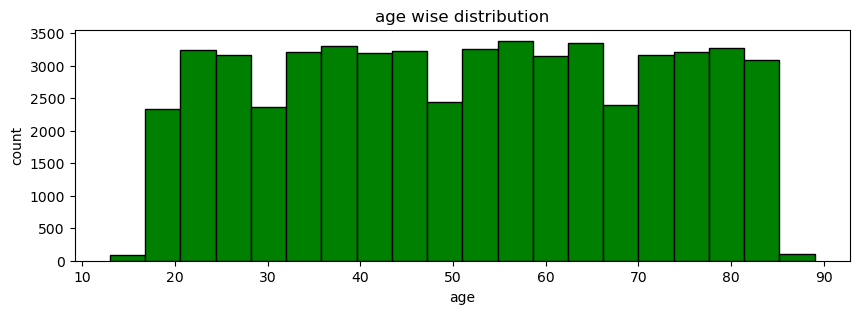

In [130]:
plt.figure(figsize=(10,3))
plt.hist(df['age'],bins=20,color='green',edgecolor='black')
plt.xlabel('age')
plt.ylabel('count')
plt.title('age wise distribution')
plt.show()

Text(0.5, 1.0, 'Age vs Billing amount')

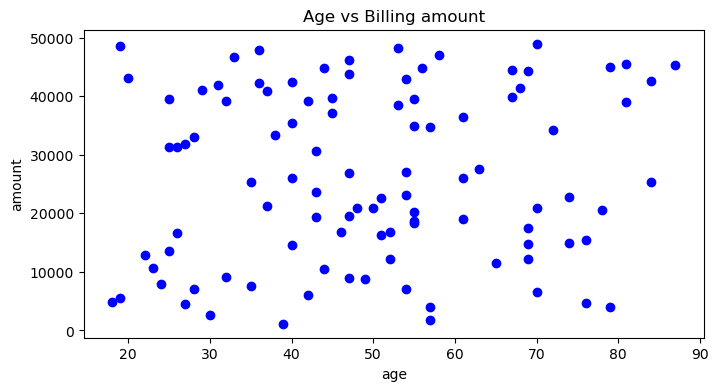

In [147]:
sample_df=df.sample(100,random_state=1)
plt.figure(figsize=(8,4))
plt.scatter(sample_df['age'],sample_df['billing_amount'],color='blue',label='billing_amount')
plt.xlabel('age')
plt.ylabel('amount')
plt.title('Age vs Billing amount')

In [154]:
df['admission_month']=df['date_of_admission'].dt.to_period('M')
bill_by_month=df.groupby('admission_month')['billing_amount'].mean().round(0)


([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30,
  31,
  32,
  33,
  34,
  35,
  36,
  37,
  38,
  39,
  40,
  41,
  42,
  43,
  44,
  45,
  46,
  47,
  48,
  49,
  50,
  51,
  52,
  53,
  54,
  55,
  56,
  57,
  58,
  59,
  60],
 [Text(0, 0, '2019-05'),
  Text(1, 0, '2019-06'),
  Text(2, 0, '2019-07'),
  Text(3, 0, '2019-08'),
  Text(4, 0, '2019-09'),
  Text(5, 0, '2019-10'),
  Text(6, 0, '2019-11'),
  Text(7, 0, '2019-12'),
  Text(8, 0, '2020-01'),
  Text(9, 0, '2020-02'),
  Text(10, 0, '2020-03'),
  Text(11, 0, '2020-04'),
  Text(12, 0, '2020-05'),
  Text(13, 0, '2020-06'),
  Text(14, 0, '2020-07'),
  Text(15, 0, '2020-08'),
  Text(16, 0, '2020-09'),
  Text(17, 0, '2020-10'),
  Text(18, 0, '2020-11'),
  Text(19, 0, '2020-12'),
  Text(20, 0, '2021-01'),
  Text(21, 0, '2021-02'),
  Text(22, 0, '2021-03'),
  Text(23, 0, '2021-04'),
  Text(24, 0, '2021-05'),
  T

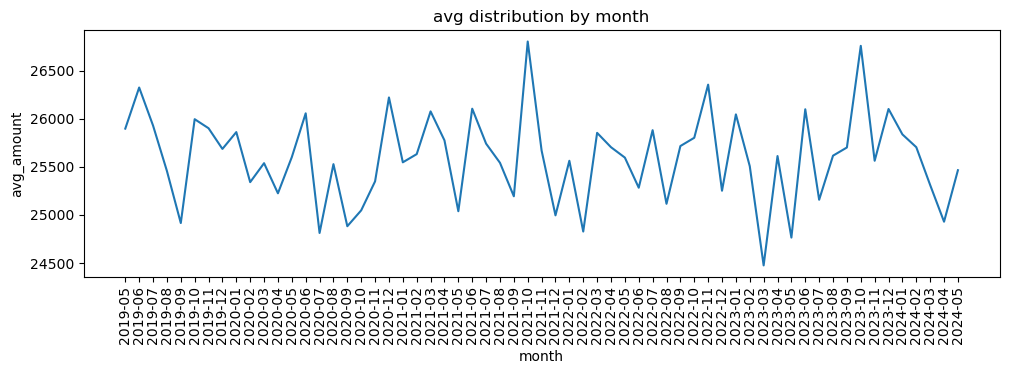

In [169]:
plt.figure(figsize=(10,3))
plt.plot(bill_by_month.index.astype(str),bill_by_month.values)
plt.tight_layout()
plt.title('avg distribution by month')
plt.xlabel('month')
plt.ylabel('avg_amount')
plt.xticks(rotation=90)